# 01 — Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/raw_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (12872, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,BuyLaptop
0,459369,Male,Yes,40,No,Engineer,NaN,Average,6.0,Yes
1,463049,Male,Yes,51,No,Executive,4.0,High,4.0,Yes
2,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,No
3,467962,Female,No,20,No,Healthcare,0.0,Low,NaN,No
4,461987,Female,Yes,43,No,Engineer,1.0,Average,2.0,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12872 entries, 0 to 12871
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               12872 non-null  int64  
 1   Gender           12872 non-null  object 
 2   Ever_Married     12586 non-null  object 
 3   Age              12872 non-null  int64  
 4   Graduated        12756 non-null  object 
 5   Profession       12704 non-null  object 
 6   Work_Experience  11474 non-null  float64
 7   Spending_Score   12872 non-null  object 
 8   Family_Size      12422 non-null  float64
 9   BuyLaptop        12872 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1005.8+ KB


In [4]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,12872.000000,12872.000000,11474.000000,12422.000000
mean,463474.017402,47.297933,2.571727,2.942360
std,2584.109074,17.435904,3.291994,1.566874
min,458982.000000,18.000000,0.000000,1.000000
25%,461305.750000,33.000000,0.000000,2.000000
50%,463492.500000,45.000000,1.000000,3.000000
75%,465596.000000,60.000000,4.000000,4.000000
max,467974.000000,89.000000,16.000000,10.000000


## Missing Values

In [5]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Missing %': pct})

,Missing,Missing %
ID,0,0.00
Gender,0,0.00
Ever_Married,286,2.22
Age,0,0.00
Graduated,116,0.90
Profession,168,1.31
Work_Experience,1398,10.86
Spending_Score,0,0.00
Family_Size,450,3.50
BuyLaptop,0,0.00


## Distributions

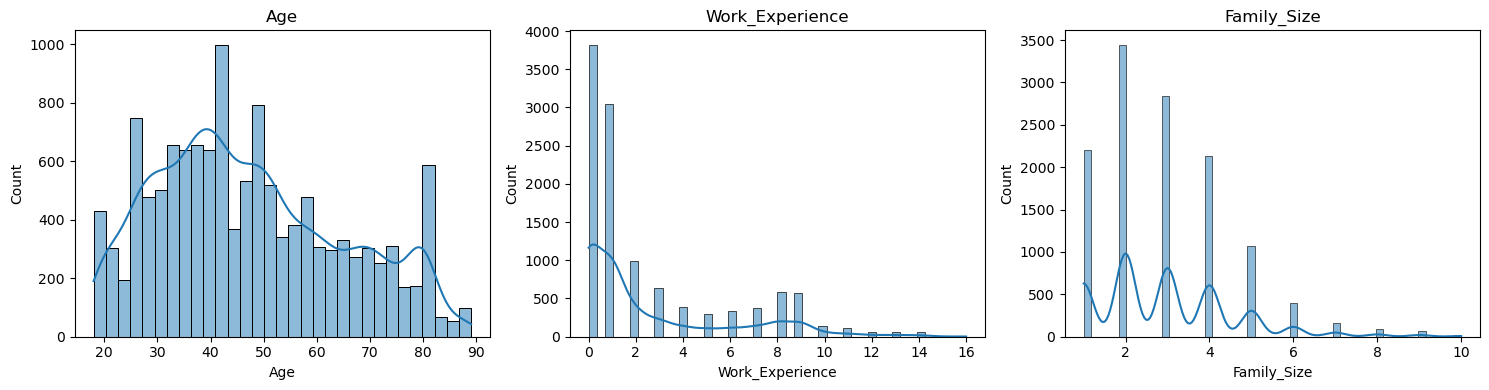

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

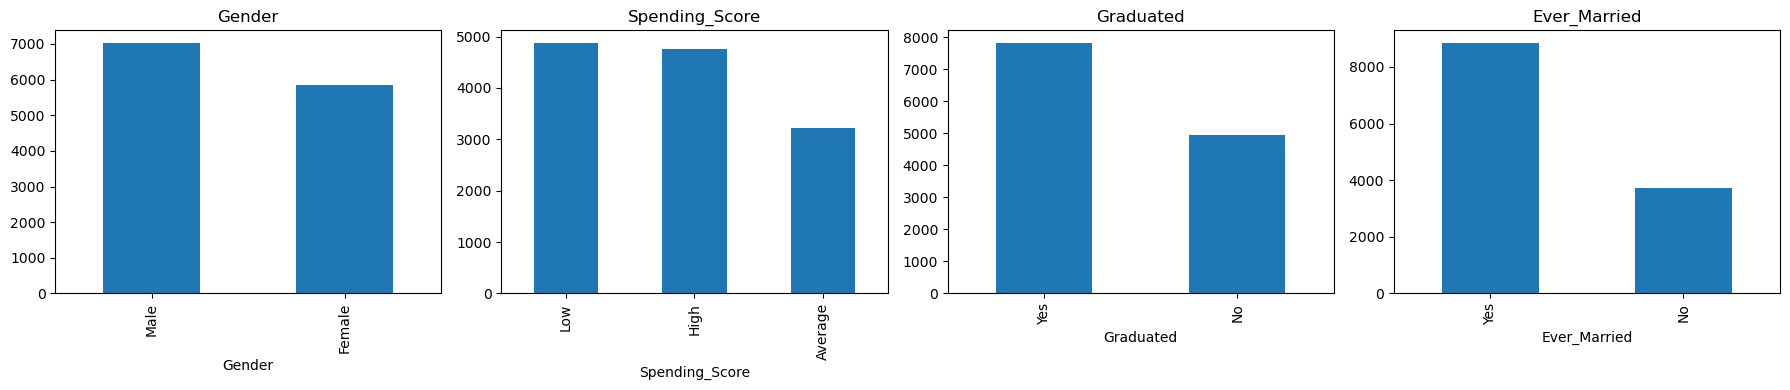

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Gender', 'Spending_Score', 'Graduated', 'Ever_Married','BuyLaptop']):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlation (numeric only)

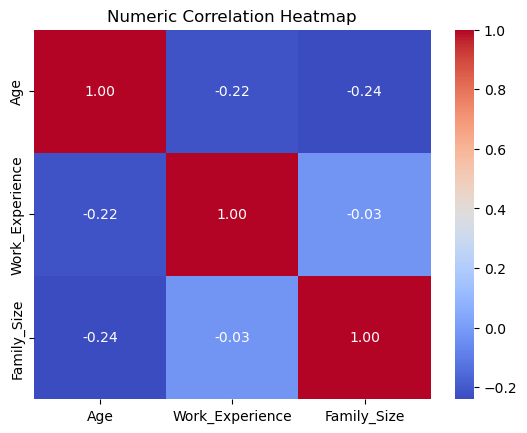

In [8]:
numerics = df.select_dtypes(include='number').drop(columns=['ID'])
sns.heatmap(numerics.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Correlation Heatmap')
plt.show()